Matrice R créée : 943 utilisateurs, 1600 films.
Début de la descente de gradient...
  Boucle 0/100
  Boucle 10/100
  Boucle 20/100
  Boucle 30/100
  Boucle 40/100
  Boucle 50/100
  Boucle 60/100
  Boucle 70/100
  Boucle 80/100
  Boucle 90/100
(Bandit Pur) Meilleur film trouvé à l'étape t=5
(Hybride) Meilleur film trouvé à l'étape t=44


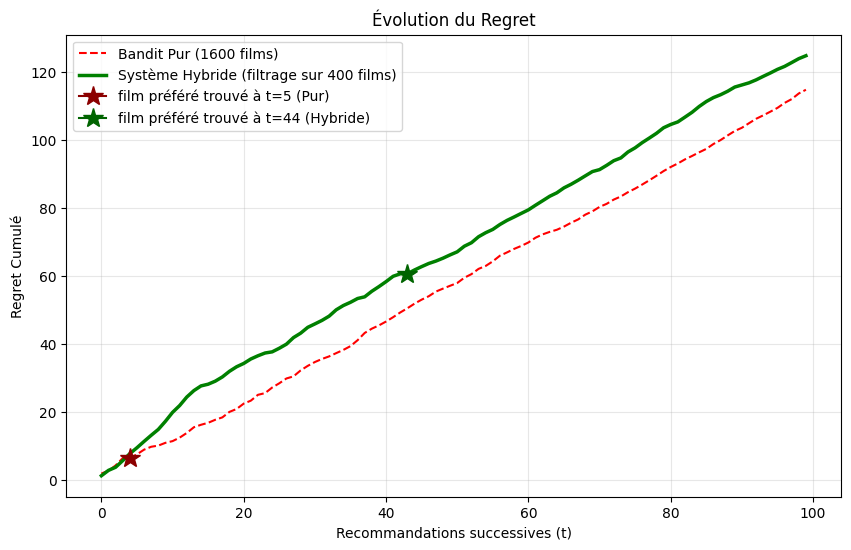

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


#Utilisation de la base de donnée MovieLens pour crée la matrice R

url = 'http://files.grouplens.org/datasets/movielens/ml-100k/u.data'
df = pd.read_csv(url, sep='\t', names=['user_id', 'item_id', 'rating', 'timestamp'])

# On garde seulement 1500 utilisateurs (les + actifs) et 1600 films pour que ça tourne plus vite
top_users = df['user_id'].value_counts().index[:1500]
top_movies = df['item_id'].value_counts().index[:1600]
df = df[df['user_id'].isin(top_users) & df['item_id'].isin(top_movies)]

user_mapping = {id_u: i for i, id_u in enumerate(top_users)}
movie_mapping = {id_m: i for i, id_m in enumerate(top_movies)}

n = len(user_mapping) # 1500
m = len(movie_mapping) # 1600

# Création de la matrice R remplie de -1
R = np.full((n, m), -1.0)

# Remplissage de R
for _, row in df.iterrows():
    u = user_mapping[row['user_id']]
    i = movie_mapping[row['item_id']]
    R[u][i] = row['rating']

# Création de la liste des notes connues 
connues = []
for u in range(n):
    for i in range(m):
        if R[u][i] != -1:
            connues.append((u, i))

print(f"Matrice R créée : {n} utilisateurs, {m} films.")


# ETAPE DE LA FACTORISATION MATRICIEL, DESCENTE DE GRADIENT 

k = 25 # Nb de facteurs latents
entrainement = 100 

def descente_de_g(nu, lambd):
    print("Début de la descente de gradient...")
    P = np.random.rand(n, k) * 0.1
    Q = np.random.rand(m, k) * 0.1
    historique = []

    for boucle in range(entrainement):
        for u, i in connues:
            # calcul de l'erreur de la prédiction
            prevision = np.dot(P[u], Q[i])
            erreur_ui = R[u][i] - prevision 
            
            # maj de P et Q
            P[u] = np.maximum(0, P[u] + nu * (erreur_ui * Q[i] - lambd * P[u]))
            Q[i] = np.maximum(0, Q[i] + nu * (erreur_ui * P[u] - lambd * Q[i]))

        erreur_totale = 0
        for u, i in connues:
            erreur_totale += (R[u][i] - np.dot(P[u], Q[i].T))**2   

        historique.append(erreur_totale)
        
        if boucle % 10 == 0:
            print(f"  Boucle {boucle}/{entrainement}")

    return historique, P, Q


# ALGORITHME DE SIMMILARITÉ COSINUS 


def fusion(l1, l2):
    if len(l1) == 0: return l2
    if len(l2) == 0: return l1
    
    if l1[0][1] > l2[0][1]:
        return [l1[0]] + fusion(l1[1:], l2)
    else:
        return [l2[0]] + fusion(l1, l2[1:])

def tri_fusion(l):
    if len(l) <= 1: return l
    milieu = len(l) // 2
    gauche = l[:milieu]
    droite = l[milieu:]
    return fusion(tri_fusion(gauche), tri_fusion(droite))

def cosine_similarity(i, Q, n_candidats):
    objet = Q[i]
    norme_objet = np.linalg.norm(objet)
    scores = []
    
    for j in range(len(Q)):
        if j == i:
            continue
            
        v_j= Q[j]
        norme_j = np.linalg.norm(v_j)
        
        produit_scalaire = np.dot(objet, v_j)
        similitude = produit_scalaire / (norme_objet * norme_j + 1e-9)
        scores.append((j, similitude))
    
    scores_tries = tri_fusion(scores)
    return scores_tries[:n_candidats]


# DEBUT DE L'ALGORITHME DES BANDITS MANCHOTS

# - SIMMULATION PURE SANS UTILISATION DE LA SIMMILARITÉ COSINUS

def simulation_pure(Q_final, index_film_depart, theta_reel, alpha, T):
    deja_vus = [index_film_depart]
    
    A = np.identity(k)
    b = np.zeros(k)

    historique_regret = []
    regret_cumule = 0
    t_meilleur_trouve = None

    notes_possibles_absolues = [np.dot(Q_final[j], theta_reel) for j in range(len(Q_final))]
    meilleure_note_absolue = max(notes_possibles_absolues)

    for t in range(1, T + 1):
        A_inv = np.linalg.inv(A) 
        theta_chapeau = np.dot(A_inv, b) 
        scores_ucb = []
        
        # L'algorithme pur balaye TOUS les films existants
        for film in range(len(Q_final)):
            if film in deja_vus:
                continue 
            
            x = Q_final[film] 
            exploitation = np.dot(theta_chapeau, x)
            exploration = alpha * np.sqrt(np.dot(x.T, np.dot(A_inv, x)))
            scores_ucb.append((exploitation + exploration, film))
        
        if not scores_ucb: break
        
        meilleur_score, film_choisi = max(scores_ucb, key=lambda item: item[0])
        deja_vus.append(film_choisi)

        q_choisi = Q_final[film_choisi]
        epsilon = np.random.normal(0, 0.5) 
        note_recue = np.dot(q_choisi, theta_reel) + epsilon
        
        A = A + np.outer(q_choisi, q_choisi)
        b = b + note_recue * q_choisi
        
        regret_instantane = meilleure_note_absolue - np.dot(q_choisi, theta_reel)
        
        # Détection du moment où il trouve le meilleur film absolu
        if regret_instantane < 1e-5 and t_meilleur_trouve is None:
            t_meilleur_trouve = t
            print(f"(Bandit Pur) Meilleur film trouvé à l'étape t={t}")
            
        regret_cumule += max(0, regret_instantane)
        historique_regret.append(regret_cumule)

    return historique_regret, t_meilleur_trouve



# ALGORITHME AVEC LA SIMMILARITÉ COSINUS 

def simulation_hybride(Q_final, index_film_depart, theta_reel, alpha, nb_candidats, T):
    deja_vus = [index_film_depart]
    dernier_film_vu = index_film_depart # Pivot pour le cosinus 
    
    A = np.identity(k)
    b = np.zeros(k)

    historique_regret = []
    regret_cumule = 0
    t_meilleur_trouve = None

    notes_possibles_absolues = [np.dot(Q_final[j], theta_reel) for j in range(len(Q_final))]
    meilleure_note_absolue = max(notes_possibles_absolues)

    for t in range(1, T + 1):
        recos_brutes = cosine_similarity(dernier_film_vu, Q_final, nb_candidats)
        indices_candidats = [id_film for id_film, score in recos_brutes]

        A_inv = np.linalg.inv(A) 
        theta_chapeau = np.dot(A_inv, b) 
        scores_ucb = []
        
        for film in indices_candidats:
            if film in deja_vus:
                continue 
            
            x = Q_final[film] 
            exploitation = np.dot(theta_chapeau, x)
            exploration = alpha * np.sqrt(np.dot(x.T, np.dot(A_inv, x)))
            scores_ucb.append((exploitation + exploration, film))
        
        # Si le filtre cosinus n'a ramené QUE des films déjà vus, on arrête
        if not scores_ucb: break
        
        meilleur_score, film_choisi = max(scores_ucb, key=lambda item: item[0])
        deja_vus.append(film_choisi)

        q_choisi = Q_final[film_choisi]
        epsilon = np.random.normal(0, 0.5) 
        note_recue = np.dot(q_choisi, theta_reel) + epsilon
        
        A = A + np.outer(q_choisi, q_choisi)
        b = b + note_recue * q_choisi
        
        # maj du pivot 
        dernier_film_vu = film_choisi
        
        regret_instantane = meilleure_note_absolue - np.dot(q_choisi, theta_reel)
        
        # Détection du moment où il trouve le meilleur film
        if regret_instantane < 1e-5 and t_meilleur_trouve is None:
            t_meilleur_trouve = t
            print(f"(Hybride) Meilleur film trouvé à l'étape t={t}")

        regret_cumule += max(0, regret_instantane)
        historique_regret.append(regret_cumule)

    return historique_regret, t_meilleur_trouve



# AFFICHAGE DES RÉSULTATS 

#Apprentissage
hist, P_final, Q_final = descente_de_g(0.01, 0.1)

#Utilisateur test (profil du 1er utilisateur
theta_test = P_final[0]

# on lance la recherche sur un film aléatoire au début 
film_depart = 19

#Lancement des simulations (T=100)
T_simu = 100
regret_pur, t_pur = simulation_pure(Q_final, film_depart, theta_test, alpha=1.5, T=T_simu)
regret_hyb, t_hyb = simulation_hybride(Q_final, film_depart, theta_test, alpha=1.5, nb_candidats=400, T=T_simu)

#Graphique
plt.figure(figsize=(10, 6))
plt.plot(regret_pur, color='red', linestyle='--', label="Bandit Pur (1600 films)")
plt.plot(regret_hyb, color='green', linewidth=2.5, label="Système Hybride (filtrage sur 400 films)")

# Ajout des étoiles pour marquer quand on a trouvé le meilleur film 
if t_pur is not None:
    plt.plot(t_pur-1, regret_pur[t_pur-1], marker='*', markersize=15, color='darkred', label=f"film préféré trouvé à t={t_pur} (Pur)")
if t_hyb is not None:
    plt.plot(t_hyb-1, regret_hyb[t_hyb-1], marker='*', markersize=15, color='darkgreen', label=f"film préféré trouvé à t={t_hyb} (Hybride)")

plt.title("Évolution du Regret")
plt.xlabel("Recommandations successives (t)")
plt.ylabel("Regret Cumulé")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()